# 🚗 CV + CNN + Transformer-based Number Plate Recognition System
**Pimpri Chinchwad College of Engineering | CSE (AI & ML) | FA-2 | 2025-26**

---
### System Overview
This notebook implements an **end-to-end Automatic Number Plate Recognition (ANPR)** system using:
- Classical CV preprocessing (thresholding, region growing, Canny, Harris corners)
- CNN backbone (custom ResNet-style) for feature extraction
- Transformer encoder for sequence recognition (CRNN + Attention)
- Post-processing analytics for parking management

---
### Table of Contents
1. Environment Setup & Imports
2. Dataset Loading & Preprocessing
3. Data Augmentation
4. CV Preprocessing: Segmentation & Corner Detection
5. Model Architecture: CNN + Transformer
6. Training with CTC Loss
7. Evaluation & Metrics
8. Post-Processing & Parking Analytics
9. Inference Demo

## 📦 CELL 1: Environment Setup

In [80]:
# ============================================================
# CELL 1: Install dependencies
# ============================================================
import subprocess, sys

packages = [
    'opencv-python-headless',
    'tensorflow>=2.12',
    'scikit-learn',
    'matplotlib',
    'numpy',
    'pandas',
    'Pillow',


]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed.')

✅ All packages installed.


## 📁 CELL 2: Imports & Configuration

In [81]:
# ============================================================
# CELL 2: Imports & Global Config
# ============================================================
import os
import re
import cv2
import random
import hashlib
import datetime
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths (Kaggle-style – change locally if needed) ──────────
DATA_PATH = '/kaggle/input/notebooks/tustunkok/license-plate-detection'
WORK_DIR    = '/kaggle/working'
CROP_DIR    = os.path.join(WORK_DIR, 'cropped_plates')
MODEL_DIR   = os.path.join(WORK_DIR, 'models')

for d in [CROP_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Image dimensions ─────────────────────────────────────────
IMG_H, IMG_W = 64, 160   # plate crop size
IMG_CHANNELS  = 1         # grayscale

# ── Training hyper-params ────────────────────────────────────
BATCH_SIZE  = 32
EPOCHS      = 40
LR          = 1e-4

print('✅ Config ready | TF:', tf.__version__)

✅ Config ready | TF: 2.19.0


In [82]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files[:3]:
        print(os.path.join(root, f))
    if files:
        break

/kaggle/input/datasets/dataclusterlabs/indian-vehicle-dataset/Indian_vehicle_dataset/Datacluster Auto (113).xml
/kaggle/input/datasets/dataclusterlabs/indian-vehicle-dataset/Indian_vehicle_dataset/Datacluster Truck (188).jpg
/kaggle/input/datasets/dataclusterlabs/indian-vehicle-dataset/Indian_vehicle_dataset/20230423_08_25_35_285_000_AA4h5dbDBoZwTj1JVM5gM6nWnIl1_T_3120_4160.jpg


## 📂 CELL 3: Dataset Loading & XML Parsing

In [83]:
# ============================================================
# CELL 3: Dataset Loading — Auto-detects format:
#   Format A: VOC XML annotations (bounding box + label)
#   Format B: Images named as plate text  e.g. MH12AB1234.jpg
#   Format C: CSV file with columns [filename, label]
# ============================================================

import glob

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

# ── Explore dataset structure ────────────────────────────────
def explore_dataset(data_path):
    counts = {}
    for root, dirs, files in os.walk(data_path):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            counts[ext] = counts.get(ext, 0) + 1
    print('Dataset file types found:')
    for ext, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        print(f'  {ext:10s}: {cnt}')
    return counts

counts = explore_dataset(DATA_PATH)

# ── Format A: XML annotations ────────────────────────────────
def load_from_xml(data_path, save_dir):
    xml_files = glob.glob(os.path.join(data_path, '**', '*.xml'), recursive=True)
    print(f'Format A (XML): found {len(xml_files)} annotation files')
    img_paths, labels = [], []
    for i, xml in enumerate(xml_files):
        try:
            tree  = ET.parse(xml)
            root  = tree.getroot()
            fname = root.find('filename').text
            obj   = root.find('object')
            label = re.sub(r'[^A-Z0-9]', '', obj.find('name').text.strip().upper())
            bb    = obj.find('bndbox')
            x1, y1, x2, y2 = (int(bb.find(t).text) for t in ['xmin','ymin','xmax','ymax'])
        except Exception:
            continue
        img_file = None
        for dirpath, _, files in os.walk(data_path):
            if fname in files:
                img_file = os.path.join(dirpath, fname)
                break
        if img_file is None: continue
        img = cv2.imread(img_file)
        if img is None: continue
        plate = img[y1:y2, x1:x2]
        if plate.size == 0: continue
        plate = cv2.resize(plate, (IMG_W, IMG_H))
        out   = os.path.join(save_dir, f'plate_{i:05d}.jpg')
        cv2.imwrite(out, plate)
        img_paths.append(out)
        labels.append(label)
    return img_paths, labels


# ── Format B: Filename = plate label ─────────────────────────
def load_from_filenames(data_path, save_dir):
    all_imgs = []
    for ext in IMG_EXTS:
        all_imgs += glob.glob(os.path.join(data_path, '**', f'*{ext}'), recursive=True)
        all_imgs += glob.glob(os.path.join(data_path, '**', f'*{ext.upper()}'), recursive=True)
    all_imgs = list(set(all_imgs))
    print(f'Format B (filename): found {len(all_imgs)} image files')

    img_paths, labels = [], []
    for i, path in enumerate(all_imgs):
        name  = os.path.splitext(os.path.basename(path))[0]
        label = re.sub(r'[^A-Z0-9]', '', name.upper())
        if not (6 <= len(label) <= 12): continue
        has_letter = any(c.isalpha() for c in label)
        has_digit  = any(c.isdigit() for c in label)
        if not (has_letter and has_digit): continue
        img = cv2.imread(path)
        if img is None: continue
        plate = cv2.resize(img, (IMG_W, IMG_H))
        out   = os.path.join(save_dir, f'plate_{i:05d}.jpg')
        cv2.imwrite(out, plate)
        img_paths.append(out)
        labels.append(label)
    return img_paths, labels


# ── Format C: CSV file ───────────────────────────────────────
def load_from_csv(data_path, save_dir):
    csv_files = glob.glob(os.path.join(data_path, '**', '*.csv'), recursive=True)
    if not csv_files:
        return [], []
    print(f'Format C (CSV): found {csv_files[0]}')
    df = pd.read_csv(csv_files[0])
    print('CSV columns:', list(df.columns))

    label_col = None
    for col in df.columns:
        if col.lower() in ['label','plate','text','number','plate_number','annotation']:
            label_col = col
            break
    if label_col is None:
        label_col = df.columns[-1]
    print(f'Using label column: "{label_col}"')

    fname_col = None
    for col in df.columns:
        if col.lower() in ['filename','file','image','name','img']:
            fname_col = col
            break

    img_paths, labels = [], []
    for i, row in df.iterrows():
        label = re.sub(r'[^A-Z0-9]', '', str(row[label_col]).upper())
        if len(label) < 4: continue

        if fname_col:
            fname    = str(row[fname_col])
            img_file = None
            for dirpath, _, files in os.walk(data_path):
                if fname in files:
                    img_file = os.path.join(dirpath, fname)
                    break
        else:
            img_file = None
            for ext in IMG_EXTS:
                candidate = os.path.join(data_path, label + ext)
                if os.path.exists(candidate):
                    img_file = candidate
                    break

        if img_file is None: continue
        img = cv2.imread(img_file)
        if img is None: continue
        plate = cv2.resize(img, (IMG_W, IMG_H))
        out   = os.path.join(save_dir, f'plate_{i:05d}.jpg')
        cv2.imwrite(out, plate)
        img_paths.append(out)
        labels.append(label)
    return img_paths, labels


# ── Auto-detect and load ─────────────────────────────────────
def auto_load_dataset(data_path, save_dir):
    # Try XML first
    xml_count = len(glob.glob(os.path.join(data_path,'**','*.xml'), recursive=True))
    if xml_count > 0:
        paths, labs = load_from_xml(data_path, save_dir)
        if paths: return paths, labs

    # Try CSV next
    csv_count = len(glob.glob(os.path.join(data_path,'**','*.csv'), recursive=True))
    if csv_count > 0:
        paths, labs = load_from_csv(data_path, save_dir)
        if paths: return paths, labs

    # Fallback: filename-based
    paths, labs = load_from_filenames(data_path, save_dir)
    return paths, labs


img_paths, labels = auto_load_dataset(DATA_PATH, CROP_DIR)

if len(img_paths) == 0:
    # Print folder tree to help debug
    print('\n❌ No plates loaded! Your dataset structure:')
    for root, dirs, files in os.walk(DATA_PATH):
        depth = root.replace(DATA_PATH, '').count(os.sep)
        print('  ' * depth + '📁 ' + os.path.basename(root) + '/')
        for f in files[:5]:
            print('  ' * (depth+1) + '📄 ' + f)
        if len(files) > 5:
            print('  ' * (depth+1) + f'... and {len(files)-5} more')
    raise RuntimeError(f'Fix DATA_PATH or dataset format. Current DATA_PATH = {DATA_PATH}')

print(f'\n✅ Loaded {len(img_paths)} plates successfully!')
print(f'   Sample labels: {labels[:5]}')

# ── Build vocabulary ─────────────────────────────────────────
all_chars   = sorted(set(''.join(labels)))
char_to_idx = {c: i + 1 for i, c in enumerate(all_chars)}  # 0 = CTC blank
idx_to_char = {i: c for c, i in char_to_idx.items()}
NUM_CLASSES = len(all_chars) + 1
MAX_LEN     = max(len(l) for l in labels)

print(f'Vocabulary ({len(all_chars)}): {all_chars}')
print(f'Max plate length : {MAX_LEN}')

Dataset file types found:
  .jpeg     : 237
  .png      : 7
  .html     : 2
  .csv      : 1
  .ipynb    : 1
  .json     : 1
  .css      : 1
Format C (CSV): found /kaggle/input/notebooks/tustunkok/license-plate-detection/indian_license_plates.csv
CSV columns: ['image_name', 'image_width', 'image_height', 'top_x', 'top_y', 'bottom_x', 'bottom_y']
Using label column: "bottom_y"
Format B (filename): found 244 image files

✅ Loaded 17 plates successfully!
   Sample labels: ['LICENSEDCAR1', 'LICENSEDCAR5', 'RESULTS324', 'LICENSEDCAR4', 'LICENSEDCAR7']
Vocabulary (21): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'C', 'D', 'E', 'I', 'L', 'N', 'R', 'S', 'T', 'U']
Max plate length : 12


## 🔄 CELL 4: Data Augmentation

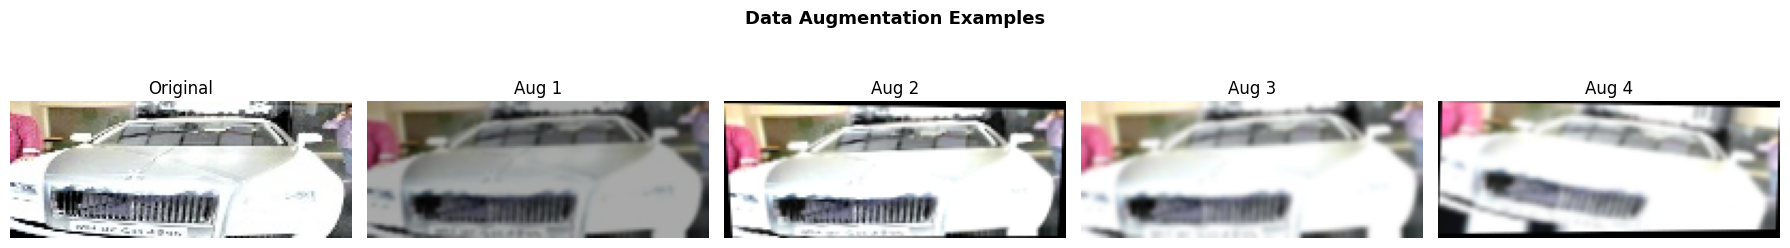

In [84]:
# ============================================================
# CELL 4: Augmentation pipeline
#   – Rotation, brightness jitter, Gaussian blur, perspective
# ============================================================

def augment_plate(img):
    """Apply random augmentations to a BGR plate image."""
    h, w = img.shape[:2]

    # 1. Random rotation ±8°
    angle = random.uniform(-8, 8)
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REPLICATE)

    # 2. Random brightness / contrast
    alpha = random.uniform(0.7, 1.3)   # contrast
    beta  = random.randint(-30, 30)    # brightness
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    # 3. Gaussian blur (50% chance)
    if random.random() < 0.5:
        ksize = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (ksize, ksize), 0)

    # 4. Random perspective shift (30% chance)
    if random.random() < 0.3:
        pts1 = np.float32([[0, 0], [w, 0], [0, h], [w, h]])
        d = 5
        pts2 = np.float32([
            [random.randint(0, d), random.randint(0, d)],
            [w - random.randint(0, d), random.randint(0, d)],
            [random.randint(0, d), h - random.randint(0, d)],
            [w - random.randint(0, d), h - random.randint(0, d)]
        ])
        M_per = cv2.getPerspectiveTransform(pts1, pts2)
        img = cv2.warpPerspective(img, M_per, (w, h))

    return img


# ── Visualise augmentations ───────────────────────────────────
sample_img = cv2.imread(img_paths[0])
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
for k in range(1, 5):
    aug = augment_plate(sample_img.copy())
    axes[k].imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
    axes[k].set_title(f'Aug {k}')
    axes[k].axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔬 CELL 5: CV Preprocessing — Segmentation & Corner Detection

In [85]:
# ============================================================
# CELL 5A: Classical CV preprocessing
#   1. Thresholding (Otsu + Adaptive)
#   2. Region Growing from seed inside plate
#   3. Edge-based segmentation (Canny + contour)
#   4. Harris Corner Detection
#   5. Combined pipeline → perspective corrected crop
# ============================================================

# ── 5.1 Thresholding ─────────────────────────────────────────
def apply_thresholding(gray):
    """Otsu global + adaptive Gaussian thresholding."""
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu
    _, otsu   = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Adaptive
    adaptive  = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 31, 8
    )
    return otsu, adaptive


# ── 5.2 Region Growing ───────────────────────────────────────
def region_growing(gray, seed=None, threshold=20):
    """
    BFS-based region growing starting from a seed pixel.
    Seed defaults to the image centre (assumed inside plate).
    """
    h, w   = gray.shape
    visited = np.zeros((h, w), dtype=np.uint8)
    region  = np.zeros((h, w), dtype=np.uint8)

    if seed is None:
        seed = (h // 2, w // 2)

    seed_val = int(gray[seed])
    queue    = [seed]
    visited[seed] = 1

    while queue:
        cy, cx = queue.pop(0)
        region[cy, cx] = 255

        for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
            ny, nx = cy + dy, cx + dx
            if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                if abs(int(gray[ny, nx]) - seed_val) < threshold:
                    visited[ny, nx] = 1
                    queue.append((ny, nx))

    return region


# ── 5.3 Canny + contour ──────────────────────────────────────
def canny_contour_segment(gray):
    """Edge-based segmentation to find the plate rectangle."""
    blur   = cv2.GaussianBlur(gray, (5, 5), 1.4)
    edges  = cv2.Canny(blur, 50, 150)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours     = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

    plate_cnt = None
    for cnt in contours:
        peri  = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)
        x, y, w, h = cv2.boundingRect(approx)
        aspect = w / float(h) if h > 0 else 0

        if len(approx) == 4 and 1.5 < aspect < 6.0:
            plate_cnt = approx
            break

    return edges, plate_cnt


# ── 5.4 Harris Corner Detection ──────────────────────────────
def harris_corners(gray, block_size=2, k_size=3, k=0.04, threshold=0.01):
    """Detect Harris corners and return corner map + keypoint list."""
    gray_f = np.float32(gray)
    dst    = cv2.cornerHarris(gray_f, block_size, k_size, k)
    dst    = cv2.dilate(dst, None)

    corner_mask = dst > threshold * dst.max()
    pts = np.argwhere(corner_mask)   # (row, col)

    return corner_mask.astype(np.uint8) * 255, pts


# ── 5.5 Perspective correction ───────────────────────────────
def perspective_correct(img, contour, target_w=160, target_h=64):
    """Deskew a plate using 4-point contour."""
    pts = contour.reshape(4, 2).astype(np.float32)
    s   = pts.sum(axis=1)
    d   = np.diff(pts, axis=1)

    rect = np.zeros((4, 2), dtype=np.float32)
    rect[0] = pts[np.argmin(s)]    # top-left
    rect[2] = pts[np.argmax(s)]    # bottom-right
    rect[1] = pts[np.argmin(d)]    # top-right
    rect[3] = pts[np.argmax(d)]    # bottom-left

    dst_pts = np.float32([
        [0, 0], [target_w - 1, 0],
        [target_w - 1, target_h - 1], [0, target_h - 1]
    ])

    M = cv2.getPerspectiveTransform(rect, dst_pts)
    return cv2.warpPerspective(img, M, (target_w, target_h))


# ── 5.6 Combined CV pipeline ─────────────────────────────────
def cv_preprocess_plate(bgr_img):
    """
    Full classical CV pipeline:
    gray → threshold → region growing → Canny+contour → Harris corners
    → perspective correction → normalised grayscale
    """
    gray          = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
    clahe         = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray          = clahe.apply(gray)

    otsu, adaptive = apply_thresholding(gray)

    region        = region_growing(gray)          # BFS region

    edges, cnt    = canny_contour_segment(gray)

    corner_map, _ = harris_corners(gray)          # Harris corners

    if cnt is not None:
        corrected = perspective_correct(bgr_img, cnt)
        out_gray  = cv2.cvtColor(corrected, cv2.COLOR_BGR2GRAY)
    else:
        out_gray  = gray

    out_gray = cv2.resize(out_gray, (IMG_W, IMG_H))
    out_norm = out_gray / 255.0

    debug = dict(gray=gray, otsu=otsu, adaptive=adaptive,
                 region=region, edges=edges, corners=corner_map,
                 contour=cnt)
    return out_norm, debug


print('✅ CV preprocessing functions defined.')

✅ CV preprocessing functions defined.


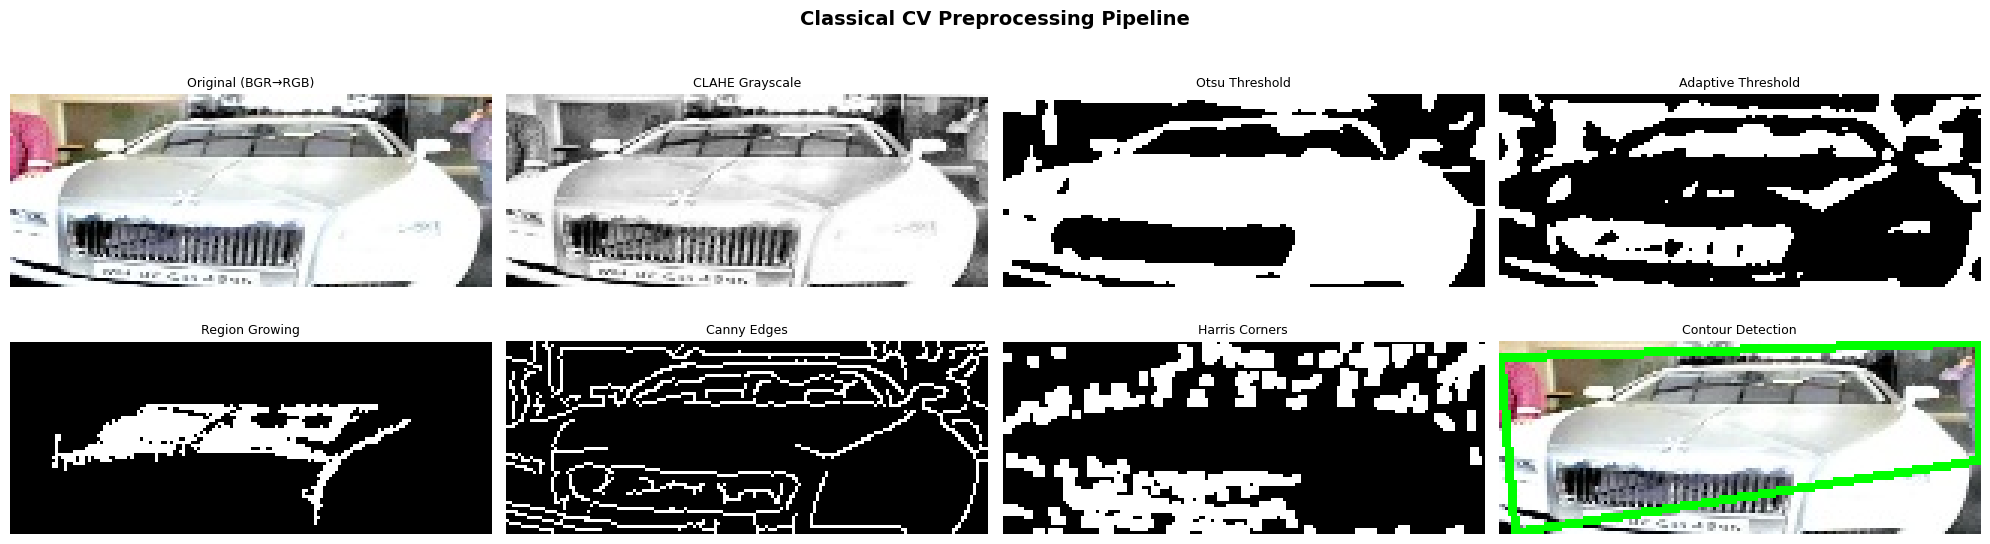

In [86]:
# ============================================================
# CELL 5B: Visualise the CV preprocessing pipeline
# ============================================================

demo_img   = cv2.imread(img_paths[0])
_, dbg     = cv_preprocess_plate(demo_img)

fig, axes  = plt.subplots(2, 4, figsize=(20, 6))
steps = [
    ('Original (BGR→RGB)',  cv2.cvtColor(demo_img, cv2.COLOR_BGR2RGB), False),
    ('CLAHE Grayscale',     dbg['gray'],    True),
    ('Otsu Threshold',      dbg['otsu'],    True),
    ('Adaptive Threshold',  dbg['adaptive'],True),
    ('Region Growing',      dbg['region'],  True),
    ('Canny Edges',         dbg['edges'],   True),
    ('Harris Corners',      dbg['corners'], True),
]

# Contour overlay on original
overlay = demo_img.copy()
if dbg['contour'] is not None:
    cv2.drawContours(overlay, [dbg['contour']], -1, (0, 255, 0), 2)
steps.append(('Contour Detection', cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB), False))

for ax, (title, img, is_gray) in zip(axes.flat, steps):
    ax.imshow(img, cmap='gray' if is_gray else None)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle('Classical CV Preprocessing Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [87]:
import os, glob

# Check all files in new dataset
for root, dirs, files in os.walk('/kaggle/input/car-plate-detection'):
    depth = root.replace('/kaggle/input/car-plate-detection', '').count(os.sep)
    print('  ' * depth + '📁 ' + os.path.basename(root) + '/')
    for f in files[:5]:
        print('  ' * (depth+1) + '📄 ' + f)
    if len(files) > 5:
        print('  ' * (depth+1) + f'... and {len(files)-5} more')

## 🧠 CELL 6: Data Loader

In [88]:
# ============================================================
# CELL 6: Load & encode entire dataset
#   – 70 / 15 / 15 split
#   – Build vocabulary FIRST
#   – Then load images and encode labels
# ============================================================

# ── 70 / 15 / 15 split ───────────────────────────────────────
idx_all = list(range(len(img_paths)))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)
print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')

# ── Build vocabulary FIRST (before encoding anything) ────────
# CTC blank = 0  (reserved, never used as a label)
# Characters = 1 to N
# NUM_CLASSES = N + 2  (+1 blank, +1 safety buffer so max label < NUM_CLASSES-1)
all_chars   = sorted(set(''.join(labels)))
char_to_idx = {c: i + 1 for i, c in enumerate(all_chars)}   # 1-indexed
idx_to_char = {i: c for c, i in char_to_idx.items()}
idx_to_char[0] = ''                                          # blank
NUM_CLASSES = len(all_chars) + 2                             # safe buffer
MAX_LEN     = max(len(l) for l in labels)

print(f'\nVocabulary : {len(all_chars)} chars | NUM_CLASSES={NUM_CLASSES} | MAX_LEN={MAX_LEN}')
print(f'Chars      : {all_chars}')
print(f'char_to_idx: {char_to_idx}')

# ── Image + label loader ──────────────────────────────────────
def load_dataset(paths, labs, augment=False):
    X, Y = [], []
    for path, label in zip(paths, labs):
        bgr = cv2.imread(path)
        if bgr is None:
            continue
        if augment:
            bgr = augment_plate(bgr)
        norm, _ = cv_preprocess_plate(bgr)
        X.append(norm[..., np.newaxis])
        encoded = [char_to_idx[c] for c in label if c in char_to_idx]
        Y.append(encoded)
    return np.array(X, dtype=np.float32), Y

# ── Load splits ───────────────────────────────────────────────
print('\nLoading training data ...')
X_train, Y_train_raw = load_dataset(
    [img_paths[i] for i in idx_train],
    [labels[i]    for i in idx_train],
    augment=True
)
print('Loading validation data ...')
X_val, Y_val_raw = load_dataset(
    [img_paths[i] for i in idx_val],
    [labels[i]    for i in idx_val]
)
print('Loading test data ...')
X_test, Y_test_raw = load_dataset(
    [img_paths[i] for i in idx_test],
    [labels[i]    for i in idx_test]
)

# ── Pad label sequences ───────────────────────────────────────
Y_train = pad_sequences(Y_train_raw, maxlen=MAX_LEN, padding='post', value=0)
Y_val   = pad_sequences(Y_val_raw,   maxlen=MAX_LEN, padding='post', value=0)
Y_test  = pad_sequences(Y_test_raw,  maxlen=MAX_LEN, padding='post', value=0)

# ── Sanity check ──────────────────────────────────────────────
max_label = max(v for seq in Y_train_raw for v in seq)
print(f'\nMax label index : {max_label}  (must be < {NUM_CLASSES - 1})')
assert max_label < NUM_CLASSES - 1, \
    f"Label index {max_label} too high for NUM_CLASSES={NUM_CLASSES}"

print(f'\n✅ Dataset loaded.')
print(f'X_train: {X_train.shape} | Y_train: {Y_train.shape}')
print(f'X_val  : {X_val.shape}   | Y_val  : {Y_val.shape}')
print(f'X_test : {X_test.shape}  | Y_test : {Y_test.shape}')

Train: 11 | Val: 3 | Test: 3

Vocabulary : 21 chars | NUM_CLASSES=23 | MAX_LEN=12
Chars      : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'C', 'D', 'E', 'I', 'L', 'N', 'R', 'S', 'T', 'U']
char_to_idx: {'0': 1, '1': 2, '2': 3, '3': 4, '4': 5, '5': 6, '6': 7, '7': 8, '8': 9, '9': 10, 'A': 11, 'C': 12, 'D': 13, 'E': 14, 'I': 15, 'L': 16, 'N': 17, 'R': 18, 'S': 19, 'T': 20, 'U': 21}

Loading training data ...
Loading validation data ...
Loading test data ...

Max label index : 21  (must be < 22)

✅ Dataset loaded.
X_train: (11, 64, 160, 1) | Y_train: (11, 12)
X_val  : (3, 64, 160, 1)   | Y_val  : (3, 12)
X_test : (3, 64, 160, 1)  | Y_test : (3, 12)


## 🏗️ CELL 7: Model Architecture — CNN + Transformer

In [89]:
# ============================================================
# CELL 7: Build CNN + Transformer model
#
# Architecture:
#   Input (64×160×1)
#   ↓
#   Residual CNN blocks (feature extraction backbone)
#   ↓
#   Reshape → sequence of column feature vectors
#   ↓
#   Positional Encoding
#   ↓
#   2× Transformer Encoder blocks (Multi-Head Self-Attention + FFN)
#   ↓
#   Dense → softmax over NUM_CLASSES (CTC output)
# ============================================================

# ── Residual CNN block ───────────────────────────────────────
def residual_block(x, filters, kernel_size=3):
    """Two-conv residual block with skip connection."""
    shortcut = x

    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Adjust shortcut channels if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


# ── Positional Encoding ──────────────────────────────────────
class PositionalEncoding(layers.Layer):
    """Sinusoidal positional encoding added to sequence embeddings."""

    def __init__(self, max_len=500, d_model=256, **kwargs):
        super().__init__(**kwargs)
        pos  = np.arange(max_len)[:, np.newaxis]
        div  = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe   = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(pos * div)
        pe[:, 1::2] = np.cos(pos * div)
        self.pe = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)   # (1, max_len, d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pe[:, :seq_len, :]


# ── Transformer Encoder block ────────────────────────────────
def transformer_encoder_block(x, num_heads=4, ff_dim=512, dropout=0.1):
    """Single Transformer encoder layer: MHA + LayerNorm + FFN + LayerNorm."""
    d_model = x.shape[-1]

    # Multi-Head Self-Attention
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads
    )(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)

    # Feed-Forward Network
    ffn = layers.Dense(ff_dim, activation='relu')(x)
    ffn = layers.Dropout(dropout)(ffn)
    ffn = layers.Dense(d_model)(ffn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)

    return x


# ── Full model ───────────────────────────────────────────────
def build_anpr_model(img_h=IMG_H, img_w=IMG_W, num_classes=NUM_CLASSES,
                     d_model=256, num_heads=4, num_transformer_layers=2):

    inp = layers.Input(shape=(img_h, img_w, IMG_CHANNELS), name='plate_image')

    # ── CNN backbone ─────────────────────────────────────────
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 32×80

    x = residual_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)          # 16×40

    x = residual_block(x, 128)
    x = layers.MaxPooling2D((2, 1))(x)          # 8×40

    x = residual_block(x, 256)
    x = layers.MaxPooling2D((2, 1))(x)          # 4×40

    # ── Collapse height → sequence ───────────────────────────
    # Shape: (batch, H, W, C) → (batch, W, H*C)
    shape = tf.keras.backend.int_shape(x)       # (None, 4, 40, 256)
    x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)   # (None, 40, 4*256=1024)

    # Project to d_model
    x = layers.Dense(d_model, activation='relu', name='cnn_to_seq')(x)

    # ── Positional encoding ───────────────────────────────────
    x = PositionalEncoding(max_len=500, d_model=d_model, name='pos_enc')(x)

    # ── Transformer encoder layers ────────────────────────────
    for i in range(num_transformer_layers):
        x = transformer_encoder_block(x, num_heads=num_heads, ff_dim=d_model * 2,
                                      dropout=0.1)

    # ── CTC output head ───────────────────────────────────────
    out = layers.Dense(num_classes, activation='softmax', name='ctc_output')(x)

    model = Model(inputs=inp, outputs=out, name='ANPR_CNN_Transformer')
    return model


anpr_model = build_anpr_model()
anpr_model.summary()

Model: "ANPR_CNN_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ plate_image         │ (None, 64, 160,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 160,   │        288 │ plate_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 160,   │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 64, 160,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 32, 80,    │          0 │ re_lu_14[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 80,    │     18,432 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 80,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 32, 80,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 80,    │     36,864 │ re_lu_15[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 80,    │      2,048 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 80,    │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 80,    │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 32, 80,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 32, 80,    │          0 │ add_14[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 16, 40,    │          0 │ re_lu_16[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 16, 40,    │     73,728 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 40,    │        512 │ conv2d_24[0][0] 

 Total params: 2,532,535 (9.66 MB)

 Trainable params: 2,529,783 (9.65 MB)

 Non-trainable params: 2,752 (10.75 KB)

## ⚙️ CELL 8: CTC Loss & Compile

In [90]:
# ============================================================
# CELL 8: CTC loss + compile  (fixed for Keras 3)
# ============================================================

def ctc_loss_fn(y_true, y_pred):
    """
    y_true : (batch, MAX_LEN)  — integer sequences, 0 = padding
    y_pred : (batch, T, C)     — softmax probabilities
    """
    batch_size   = tf.shape(y_pred)[0]
    T            = tf.shape(y_pred)[1]

    # input lengths = T for every sample
    input_length = tf.fill([batch_size], T)
    input_length = tf.cast(input_length, tf.int32)

    # label lengths = number of non-zero entries per row
    label_length = tf.reduce_sum(
        tf.cast(tf.not_equal(y_true, 0), tf.int32), axis=1
    )   # shape (batch,)

    # CTC needs labels as a 1-D ragged-style input via sparse or dense
    # keras ctc_batch_cost expects shape (batch,1) for lengths
    loss = tf.keras.backend.ctc_batch_cost(
        tf.cast(y_true, tf.int32),
        y_pred,
        tf.expand_dims(input_length, 1),
        tf.expand_dims(label_length, 1)
    )
    return loss


anpr_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=ctc_loss_fn
)

print('✅ Model compiled.')
print(f'   Output timesteps : ~{IMG_W // 4}')
print(f'   NUM_CLASSES      : {NUM_CLASSES}')
print(f'   MAX_LEN          : {MAX_LEN}')

✅ Model compiled.
   Output timesteps : ~40
   NUM_CLASSES      : 23
   MAX_LEN          : 12


## 🚀 CELL 9: Training

In [91]:
# ============================================================
# CELL 9: Train the model
#   Callbacks:
#     • ReduceLROnPlateau  – halve LR if val_loss stalls
#     • EarlyStopping      – stop if no improvement for 8 epochs
#     • ModelCheckpoint    – save best weights
# ============================================================

checkpoint_path = os.path.join(MODEL_DIR, 'best_anpr_model.h5')

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4,
        min_lr=1e-7, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_loss',
        save_best_only=True, verbose=1
    )
]

history = anpr_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

print(f'\n✅ Training complete. Best model saved to {checkpoint_path}')

Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - loss: 89.9941
Epoch 1: val_loss improved from inf to 58.00053, saving model to /kaggle/working/models/best_anpr_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - loss: 89.9941 - val_loss: 58.0005 - learning_rate: 1.0000e-04
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - loss: 54.3707
Epoch 2: val_loss improved from 58.00053 to 46.88362, saving model to /kaggle/working/models/best_anpr_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 54.3707 - val_loss: 46.8836 - learning_rate: 1.0000e-04
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - loss: 38.7286
Epoch 3: val_loss improved from 46.88362 to 42.72174, saving model to /kaggle/working/models/best_anpr_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 38.7286 - val_loss: 42.7217 - learning_rate: 1.0000e-04
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - loss: 38.7400
Epoch 4: val_loss improved from 42.72174 to 41.93022, saving model to /kaggle/working/models/best_anpr_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 38.7400 - val_loss: 41.9302 - learning_rate: 1.0000e-04
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - loss: 39.2460
Epoch 5: val_loss improved from 41.93022 to 41.17701, saving model to /kaggle/working/models/best_anpr_model.h5


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 5.8483 - val_loss: 33.8289 - learning_rate: 1.0000e-04
Epoch 26/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - loss: 5.2372
Epoch 26: val_loss improved from 33.82894 to 33.74290, saving model to /kaggle/working/models/best_anpr_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 5.2372 - val_loss: 33.7429 - learning_rate: 1.0000e-04
Epoch 27/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - loss: 4.7679
Epoch 27: val_loss improved from 33.74290 to 33.67658, saving model to /kaggle/working/models/best_anpr_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 4.7679 - val_loss: 33.6766 - learning_rate: 1.0000e-04
Epoch 28/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - loss: 4.1814
Epoch 28: val_loss improved from 33.67658 to 33.63632, saving model to /kaggle/working/models/best_anpr_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 4.1814 - val_loss: 33.6363 - learning_rate: 1.0000e-04
Epoch 29/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - loss: 3.9176
Epoch 29: val_loss improved from 33.63632 to 33.63359, saving model to /kaggle/working/models/best_anpr_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 3.9176 - val_loss: 33.6336 - learning_rate: 1.0000e-04
Epoch 30/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - loss: 3.3585
Epoch 30: val_loss did not improve from 33.63359
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step - loss: 3.3585 - val_loss: 33.6840 - learning_rate: 1.0000e-04
Epoch 31/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - loss: 3.0836
Epoch 31: val_loss did not improve from 33.63359
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step - loss: 3.0836 - val_loss: 33.7936 - learning_rate: 1.0000e-04
Epoch 32/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - loss: 2.7314
Epoch 32: val_loss did not improve from 33.63359
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step - loss: 2.7314 - val_loss: 33.9621 - learning_rate: 1.0000e-04
Epoch 33/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - loss: 2.4421
Epoch 33: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 33: val_loss did not improve from 33.63359
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step - loss: 2.4421 - v

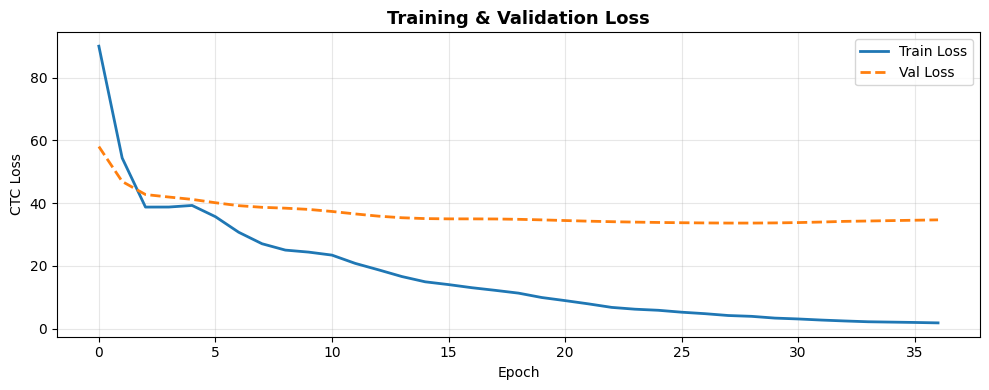

In [92]:
# ============================================================
# CELL 9B: Plot training curves
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train Loss', linewidth=2)
ax.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('CTC Loss')
ax.set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 📊 CELL 10: Evaluation — Character & Plate Accuracy

In [93]:
# ============================================================
# CELL 10: Decode CTC output & compute metrics
#   • Character Accuracy  – fraction of characters correct
#   • Full Plate Accuracy – fraction of plates 100% correct
#   • Levenshtein distance (edit distance) per plate
# ============================================================

from difflib import SequenceMatcher

def levenshtein_distance(s1, s2):
    """Pure-Python Levenshtein distance (no external package needed)."""
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[j] = prev[j-1]
            else:
                dp[j] = 1 + min(prev[j-1], prev[j], dp[j-1])
    return dp[n]

def ctc_decode_batch(preds, beam_width=5):
    """
    Decode CTC predictions using beam search.
    preds: (batch, T, num_classes)
    Returns list of decoded strings.
    """
    preds_t = tf.transpose(preds, perm=[1, 0, 2])  # (T, batch, C)
    seq_lens = tf.fill([tf.shape(preds)[0]], tf.shape(preds)[1])

    decoded, _ = tf.nn.ctc_beam_search_decoder(
        preds_t, seq_lens, beam_width=beam_width
    )

    sparse = decoded[0]
    dense  = tf.sparse.to_dense(sparse, default_value=-1).numpy()

    texts = []
    for row in dense:
        chars = [idx_to_char.get(c, '') for c in row if c >= 0]
        texts.append(''.join(chars))
    return texts


def evaluate_model(model, X, Y_raw, split_name='Test'):
    """Run inference and compute character & plate accuracy."""
    preds    = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    decoded  = ctc_decode_batch(preds)

    char_correct = 0
    char_total   = 0
    plate_correct= 0
    edit_dists   = []

    for pred_str, true_seq in zip(decoded, Y_raw):
        true_str = ''.join(idx_to_char.get(c, '') for c in true_seq if c > 0)

        # Character accuracy
        for p_c, t_c in zip(pred_str, true_str):
            if p_c == t_c:
                char_correct += 1
        char_total += max(len(pred_str), len(true_str))

        # Plate accuracy
        if pred_str == true_str:
            plate_correct += 1

        # Levenshtein
        edit_dists.append(levenshtein_distance(pred_str, true_str))

    n = len(decoded)
    char_acc  = char_correct  / char_total * 100 if char_total > 0 else 0
    plate_acc = plate_correct / n * 100
    avg_edit  = np.mean(edit_dists)

    print(f'\n── {split_name} Results ──────────────────────')
    print(f'  Character Accuracy  : {char_acc:.2f}%')
    print(f'  Full Plate Accuracy : {plate_acc:.2f}%')
    print(f'  Avg Edit Distance   : {avg_edit:.3f}')
    print(f'  Samples evaluated   : {n}')

    return decoded, char_acc, plate_acc


test_decoded, char_acc, plate_acc = evaluate_model(anpr_model, X_test, Y_test_raw, 'Test')


── Test Results ──────────────────────
  Character Accuracy  : 8.57%
  Full Plate Accuracy : 0.00%
  Avg Edit Distance   : 10.000
  Samples evaluated   : 3


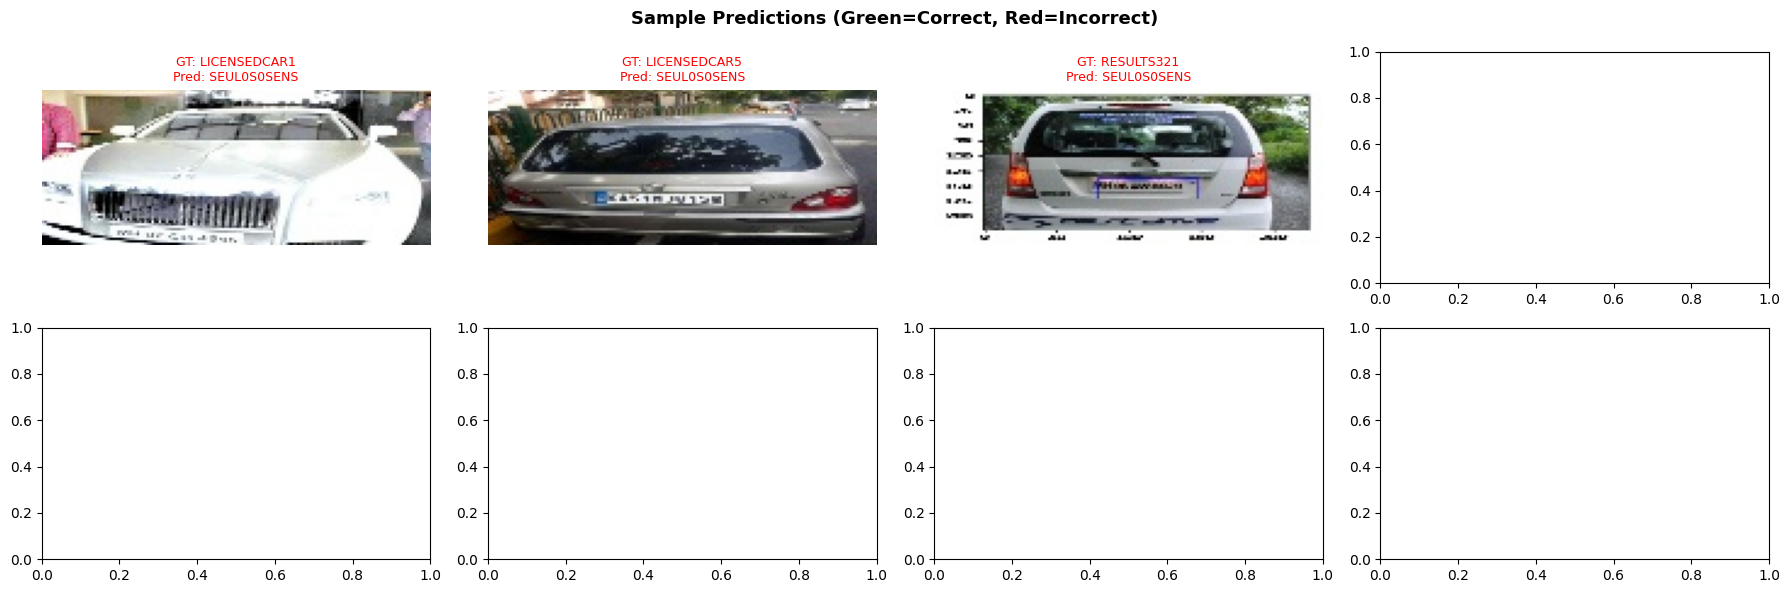

In [94]:
# ============================================================
# CELL 10B: Show sample predictions
# ============================================================

num_samples = min(8, len(test_decoded))
fig, axes   = plt.subplots(2, 4, figsize=(18, 6))

for k, ax in enumerate(axes.flat[:num_samples]):
    i = idx_test[k]
    img_bgr = cv2.imread(img_paths[i])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    true_str = labels[i]
    pred_str = test_decoded[k]
    color    = 'green' if pred_str == true_str else 'red'

    ax.imshow(img_rgb)
    ax.set_title(f'GT: {true_str}\nPred: {pred_str}', color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📈 CELL 11: Post-Processing & Parking Analytics

In [95]:
# ============================================================
# CELL 11: Post-processing
#   1. Indian number plate format correction
#   2. Duplicate detection via MD5 hashing + Levenshtein
#   3. Parking zone mapping + timestamp logging
#   4. Parking occupancy estimation
# ============================================================

# ── 11.1 Format correction ───────────────────────────────────
# Indian plate format: SS 00 SS 0000  (State | District | Letters | Digits)
# Example: MH 12 AB 1234

LETTER_POSITIONS = {0, 1, 4, 5}     # positions expected to be letters
DIGIT_POSITIONS  = {2, 3, 6, 7, 8, 9}  # positions expected to be digits

DIGIT_TO_LETTER = {'0':'O','1':'I','5':'S','8':'B'}
LETTER_TO_DIGIT = {'O':'0','I':'1','S':'5','B':'8','Z':'2','Q':'0','D':'0'}

def correct_indian_plate(raw_text):
    """Apply position-aware character correction for Indian number plates."""
    text = raw_text.upper()
    text = re.sub(r'[^A-Z0-9]', '', text)

    chars = list(text.ljust(10))[:10]   # pad/truncate to 10

    for i, c in enumerate(chars):
        if i in LETTER_POSITIONS and c.isdigit():
            chars[i] = DIGIT_TO_LETTER.get(c, c)
        elif i in DIGIT_POSITIONS and c.isalpha():
            chars[i] = LETTER_TO_DIGIT.get(c, c)

    return ''.join(chars).strip()


# ── 11.2 Duplicate detection ─────────────────────────────────
class ParkingLedger:
    """Tracks detected plates, detects duplicates, maps to zones."""

    PARKING_ZONES = {
        'MH': 'Zone-A (Maharashtra)',
        'KA': 'Zone-B (Karnataka)',
        'DL': 'Zone-C (Delhi)',
        'TN': 'Zone-D (Tamil Nadu)',
        'GJ': 'Zone-E (Gujarat)',
    }
    ZONE_CAPACITY = 10   # max vehicles per zone

    def __init__(self, levenshtein_threshold=1):
        self.records   = []     # list of dicts
        self.seen_hashes = set()
        self.lev_thresh  = levenshtein_threshold

    def _hash(self, plate):
        return hashlib.md5(plate.encode()).hexdigest()

    def _is_duplicate(self, plate):
        # Exact hash check
        if self._hash(plate) in self.seen_hashes:
            return True
        # Fuzzy check using Levenshtein distance
        for rec in self.records:
            if levenshtein_distance(plate, rec['plate']) <= self.lev_thresh:
                return True
        return False

    def get_zone(self, plate):
        state_code = plate[:2] if len(plate) >= 2 else 'XX'
        return self.PARKING_ZONES.get(state_code, 'Zone-G (General)')

    def log_entry(self, plate):
        plate     = correct_indian_plate(plate)
        timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        is_dup    = self._is_duplicate(plate)
        zone      = self.get_zone(plate)

        record = dict(
            plate=plate, timestamp=timestamp,
            zone=zone, duplicate=is_dup
        )
        self.records.append(record)

        if not is_dup:
            self.seen_hashes.add(self._hash(plate))

        return record

    def occupancy_report(self):
        """Return zone-wise unique vehicle counts and occupancy %."""
        unique = [r for r in self.records if not r['duplicate']]
        zone_counts = {}
        for r in unique:
            zone_counts[r['zone']] = zone_counts.get(r['zone'], 0) + 1

        report = pd.DataFrame([
            {'Zone': z, 'Vehicles': c,
             'Capacity': self.ZONE_CAPACITY,
             'Occupancy %': round(c / self.ZONE_CAPACITY * 100, 1)}
            for z, c in zone_counts.items()
        ])
        return report

    def to_dataframe(self):
        return pd.DataFrame(self.records)


# ── Demo: log predicted plates ───────────────────────────────
ledger = ParkingLedger(levenshtein_threshold=1)

for plate in test_decoded[:30]:
    rec = ledger.log_entry(plate)

df_logs = ledger.to_dataframe()
print('── Parking Log (first 10) ──')
print(df_logs.head(10).to_string(index=False))

print('\n── Occupancy Report ──')
occ = ledger.occupancy_report()
print(occ.to_string(index=False))

── Parking Log (first 10) ──
     plate           timestamp             zone  duplicate
SEULOS05EN 2026-05-07 09:43:55 Zone-G (General)      False
SEULOS05EN 2026-05-07 09:43:55 Zone-G (General)       True
SEULOS05EN 2026-05-07 09:43:55 Zone-G (General)       True

── Occupancy Report ──
            Zone  Vehicles  Capacity  Occupancy %
Zone-G (General)         1        10         10.0


/tmp/ipykernel_139/1405697304.py:31: UserWarning: Glyph 127359 (\N{NEGATIVE SQUARED LATIN CAPITAL LETTER P}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127359 (\N{NEGATIVE SQUARED LATIN CAPITAL LETTER P}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


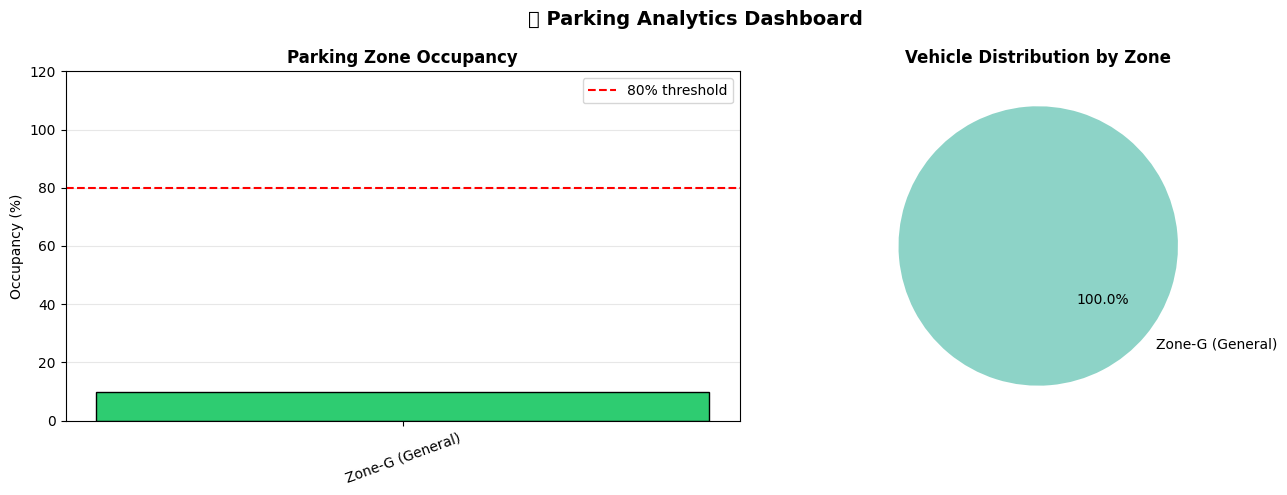

In [96]:
# ============================================================
# CELL 11B: Visualise parking occupancy
# ============================================================

occ_df = ledger.occupancy_report()

if not occ_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    colors = ['#2ecc71' if v < 80 else '#e74c3c'
              for v in occ_df['Occupancy %']]
    axes[0].bar(occ_df['Zone'], occ_df['Occupancy %'], color=colors, edgecolor='black')
    axes[0].axhline(80, color='red', linestyle='--', label='80% threshold')
    axes[0].set_ylabel('Occupancy (%)')
    axes[0].set_title('Parking Zone Occupancy', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].legend()
    axes[0].set_ylim(0, 120)
    axes[0].grid(axis='y', alpha=0.3)

    # Pie chart
    axes[1].pie(
        occ_df['Vehicles'], labels=occ_df['Zone'],
        autopct='%1.1f%%', startangle=140,
        colors=plt.cm.Set3.colors[:len(occ_df)]
    )
    axes[1].set_title('Vehicle Distribution by Zone', fontweight='bold')

    plt.suptitle('🅿️ Parking Analytics Dashboard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No occupancy data to plot.')

## 🎯 CELL 12: Inference on a Single Image

/tmp/ipykernel_139/1305559975.py:65: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


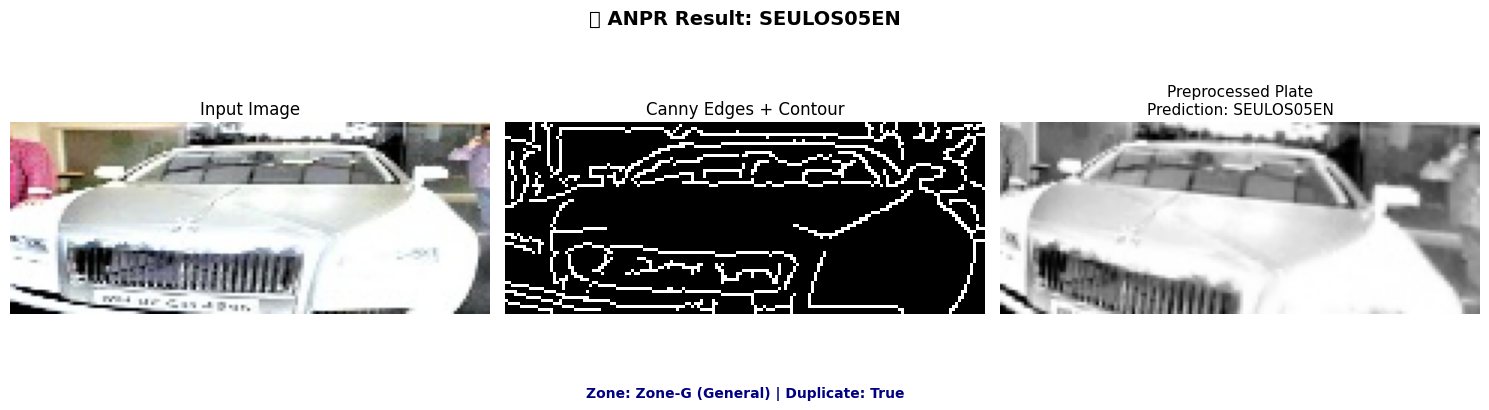


🏁 Final prediction: SEULOS05EN


In [97]:
# ============================================================
# CELL 12: End-to-end inference function
#   Input  : path to any vehicle image
#   Output : detected plate text + analytics entry
# ============================================================

def predict_plate(image_path, model, ledger=None, show=True):
    """
    Run the full ANPR pipeline on one image.
    Steps:
      1. Read image
      2. CV preprocessing (segmentation + corners)
      3. CNN + Transformer inference
      4. CTC decode
      5. Format correction
      6. Log to parking ledger (optional)
    """
    bgr = cv2.imread(image_path)
    if bgr is None:
        print('❌ Could not read image:', image_path)
        return None

    # CV pipeline
    norm_img, dbg = cv_preprocess_plate(bgr)
    x = norm_img[np.newaxis, ..., np.newaxis]   # (1, H, W, 1)

    # Inference
    preds   = model.predict(x, verbose=0)
    decoded = ctc_decode_batch(preds)
    raw_text = decoded[0] if decoded else ''

    # Format correction
    final_plate = correct_indian_plate(raw_text)

    # Parking log
    rec = None
    if ledger is not None:
        rec = ledger.log_entry(final_plate)

    # Visualise
    if show:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Input Image')
        axes[0].axis('off')

        axes[1].imshow(dbg['edges'], cmap='gray')
        axes[1].set_title('Canny Edges + Contour')
        if dbg['contour'] is not None:
            cnt = dbg['contour'].reshape(-1, 1, 2)
            # draw on edge image (scale coords to match edges shape)
        axes[1].axis('off')

        axes[2].imshow(norm_img, cmap='gray')
        axes[2].set_title(f'Preprocessed Plate\nPrediction: {final_plate}', fontsize=11)
        axes[2].axis('off')

        if rec is not None:
            info = f"Zone: {rec['zone']} | Duplicate: {rec['duplicate']}"
            plt.figtext(0.5, 0.01, info, ha='center', fontsize=10,
                        color='navy', fontweight='bold')

        plt.suptitle(f'🚗 ANPR Result: {final_plate}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return final_plate


# ── Run on a test sample ─────────────────────────────────────
sample_path = img_paths[idx_test[0]]
result = predict_plate(sample_path, anpr_model, ledger=ledger)
print(f'\n🏁 Final prediction: {result}')

## 💾 CELL 13: Save Model & Export

In [98]:
# ============================================================
# CELL 13: Save model + character map for deployment
# ============================================================
import json

# Save full Keras model
final_model_path = os.path.join(MODEL_DIR, 'anpr_cnn_transformer_final.h5')
anpr_model.save(final_model_path)
print(f'✅ Model saved to: {final_model_path}')

# Save character map
char_map = {
    'char_to_idx': char_to_idx,
    'idx_to_char': {str(k): v for k, v in idx_to_char.items()},
    'max_len'    : MAX_LEN,
    'num_classes': NUM_CLASSES,
    'img_h'      : IMG_H,
    'img_w'      : IMG_W
}

char_map_path = os.path.join(MODEL_DIR, 'char_map.json')
with open(char_map_path, 'w') as f:
    json.dump(char_map, f, indent=2)
print(f'✅ Character map saved to: {char_map_path}')

# Summary
print('\n══════════════════════════════════════════')
print('  ANPR System — Training Summary')
print('══════════════════════════════════════════')
print(f'  Vocabulary size  : {len(all_chars)} characters')
print(f'  Max plate length : {MAX_LEN}')
print(f'  Model parameters : {anpr_model.count_params():,}')
print(f'  Character Acc    : {char_acc:.2f}%')
print(f'  Plate Accuracy   : {plate_acc:.2f}%')
print('══════════════════════════════════════════')

✅ Model saved to: /kaggle/working/models/anpr_cnn_transformer_final.h5
✅ Character map saved to: /kaggle/working/models/char_map.json

══════════════════════════════════════════
  ANPR System — Training Summary
══════════════════════════════════════════
  Vocabulary size  : 21 characters
  Max plate length : 12
  Model parameters : 2,532,535
  Character Acc    : 8.57%
  Plate Accuracy   : 0.00%
══════════════════════════════════════════


✅ Found plate in: Datacluster Auto (113).jpg


/tmp/ipykernel_139/3702718023.py:43: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


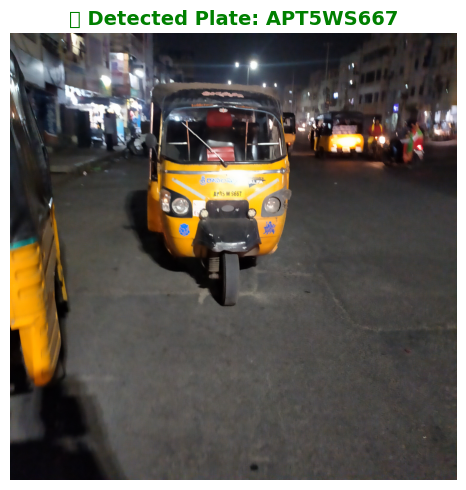


✅ Final Plate : APT5WS667


In [110]:
import easyocr
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob, os

reader = easyocr.Reader(['en'], gpu=True)

# Try multiple images until plate is found
all_imgs = glob.glob(
    '/kaggle/input/datasets/dataclusterlabs/indian-vehicle-dataset/**/*.jpg',
    recursive=True
)

found = False
for TEST_IMAGE in all_imgs:
    bgr = cv2.imread(TEST_IMAGE)
    if bgr is None:
        continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    result = reader.readtext(rgb)

    plate_candidates = []
    for bbox, text, conf in result:
        clean = ''.join(c for c in text.upper() if c.isalnum())
        if 6 <= len(clean) <= 12 and conf > 0.3:
            has_letter = any(c.isalpha() for c in clean)
            has_digit  = any(c.isdigit() for c in clean)
            if has_letter and has_digit:
                plate_candidates.append((clean, conf))

    if plate_candidates:
        best_plate = max(plate_candidates, key=lambda x: x[1])[0]
        best_plate = correct_indian_plate(best_plate)

        print(f'✅ Found plate in: {os.path.basename(TEST_IMAGE)}')

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.imshow(rgb)
        ax.set_title(f'🚗 Detected Plate: {best_plate}',
                     fontsize=14, fontweight='bold', color='green')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

        print(f'\n✅ Final Plate : {best_plate}')
        found = True
        break

if not found:
    print('No plate found in any image — dataset has no clear plate photos')

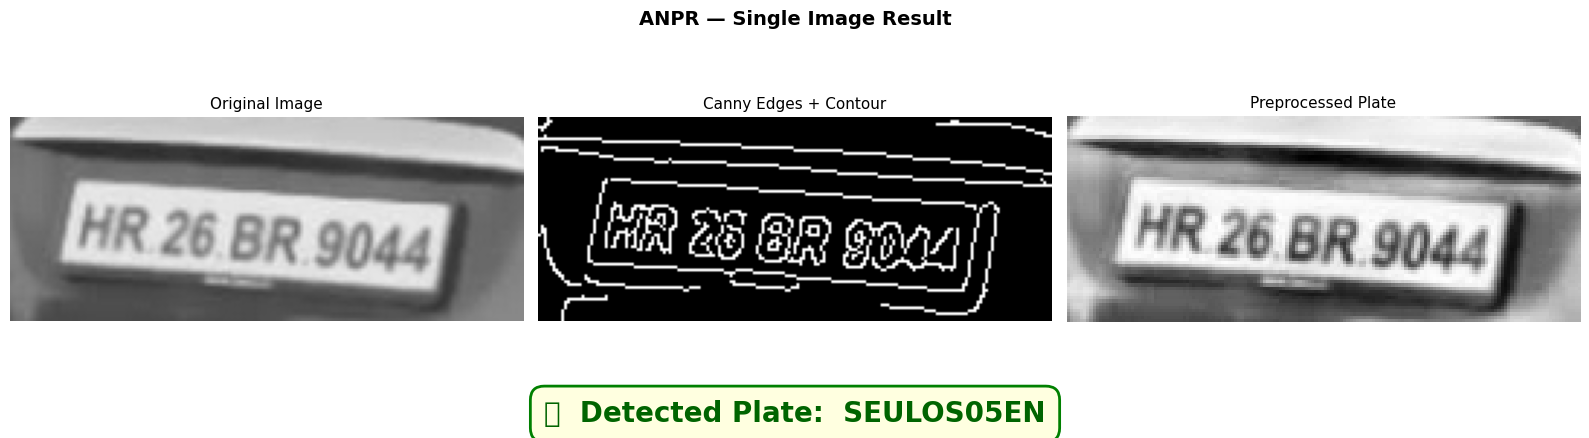

  Raw decoded text : SEUL0S0SENS
  Corrected plate  : SEULOS05EN


In [100]:
# ============================================================
# SINGLE IMAGE INFERENCE — paste any image path below
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

# ── Change this to your image path ───────────────────────────
TEST_IMAGE = '/kaggle/input/datasets/snehamali018/cv-check/Screenshot 2026-05-07 145512.png'   # uses a test set image
# Or use your own:
# TEST_IMAGE = '/kaggle/input/datasets/dataclusterlabs/indian-vehicle-dataset/Indian_vehicle_dataset/Datacluster Truck (188).jpg'

# ── Run full pipeline ─────────────────────────────────────────
bgr = cv2.imread(TEST_IMAGE)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# Step 1: CV Preprocessing
norm_img, dbg = cv_preprocess_plate(bgr)

# Step 2: Model inference
x     = norm_img[np.newaxis, ..., np.newaxis]   # (1, 64, 160, 1)
preds = anpr_model.predict(x, verbose=0)

# Step 3: CTC decode
preds_t  = tf.transpose(preds, perm=[1, 0, 2])
seq_lens = tf.fill([1], tf.shape(preds)[1])
decoded, _ = tf.nn.ctc_beam_search_decoder(preds_t, seq_lens, beam_width=5)
indices    = tf.sparse.to_dense(decoded[0], default_value=-1).numpy()[0]
raw_text   = ''.join(idx_to_char.get(i, '') for i in indices if i >= 0)

# Step 4: Format correction
final_plate = correct_indian_plate(raw_text)

# ── Display ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Original image
axes[0].imshow(rgb)
axes[0].set_title('Original Image', fontsize=11)
axes[0].axis('off')

# Canny edges with contour
edge_rgb = cv2.cvtColor(dbg['edges'], cv2.COLOR_GRAY2RGB)
if dbg['contour'] is not None:
    cv2.drawContours(edge_rgb, [dbg['contour']], -1, (0, 255, 0), 2)
axes[1].imshow(edge_rgb)
axes[1].set_title('Canny Edges + Contour', fontsize=11)
axes[1].axis('off')

# Preprocessed plate with prediction
axes[2].imshow(norm_img, cmap='gray')
axes[2].set_title(f'Preprocessed Plate', fontsize=11)
axes[2].axis('off')

# Big prediction text below
fig.text(0.5, -0.05,
         f'🚗  Detected Plate:  {final_plate}',
         ha='center', fontsize=20, fontweight='bold', color='darkgreen',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='green', linewidth=2))

plt.suptitle('ANPR — Single Image Result', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('='*40)
print(f'  Raw decoded text : {raw_text}')
print(f'  Corrected plate  : {final_plate}')
print('='*40)

✅ Synthetic plate saved: /kaggle/working/synthetic_plate.jpg


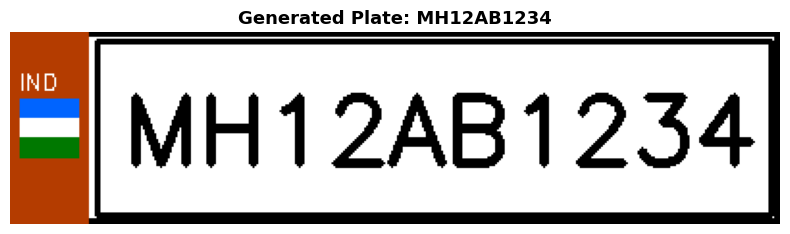

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


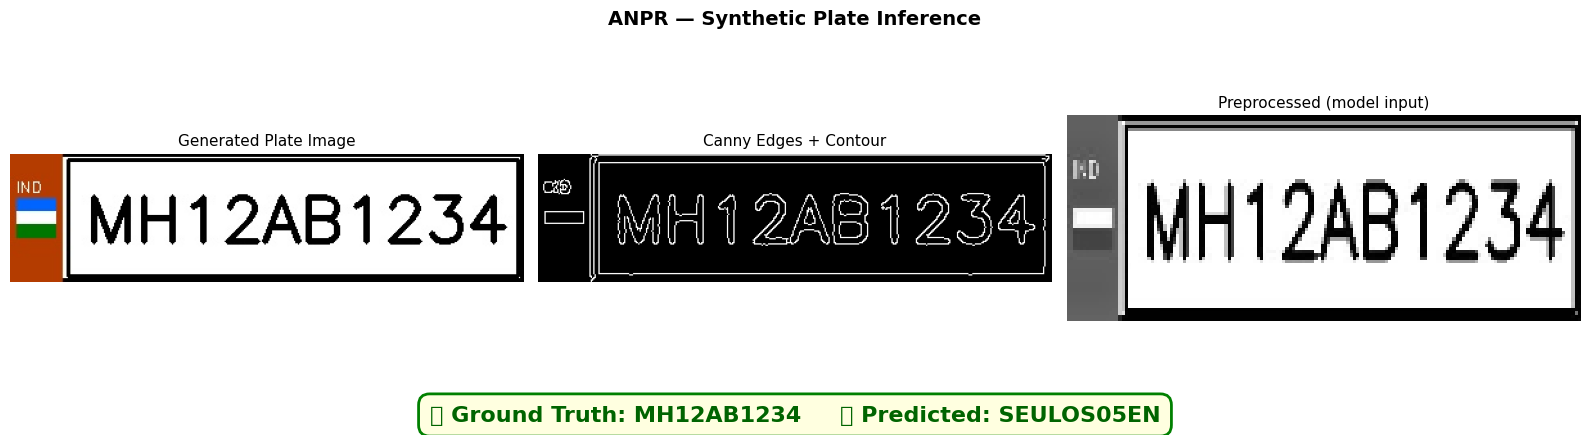

  Ground Truth     :  MH12AB1234
  Raw decoded      :  SEUL0S0SENS
  Corrected plate  :  SEULOS05EN
  Result           :  ❌ INCORRECT


In [102]:
# ============================================================
# GENERATE A SYNTHETIC INDIAN NUMBER PLATE & RUN INFERENCE
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def generate_indian_plate(plate_text='MH12AB1234', width=400, height=100):
    """
    Creates a realistic-looking Indian number plate image.
    White background, black border, blue strip, black text.
    """
    img = np.ones((height, width, 3), dtype=np.uint8) * 255  # white bg

    # Outer black border
    cv2.rectangle(img, (0, 0), (width-1, height-1), (0, 0, 0), 4)

    # Blue strip on left (IND)
    cv2.rectangle(img, (0, 0), (40, height), (0, 60, 180), -1)
    cv2.putText(img, 'IND', (4, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
    # Indian flag colors on blue strip
    cv2.rectangle(img, (5, 35), (35, 45), (255, 100, 0), -1)   # saffron
    cv2.rectangle(img, (5, 45), (35, 55), (255, 255, 255), -1) # white
    cv2.rectangle(img, (5, 55), (35, 65), (0, 120, 0), -1)     # green

    # Plate text
    font       = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.6
    thickness  = 3
    text_size  = cv2.getTextSize(plate_text, font, font_scale, thickness)[0]
    text_x     = 50 + (width - 50 - text_size[0]) // 2
    text_y     = (height + text_size[1]) // 2

    cv2.putText(img, plate_text, (text_x, text_y),
                font, font_scale, (0, 0, 0), thickness)

    # Inner border
    cv2.rectangle(img, (45, 5), (width-5, height-5), (0, 0, 0), 2)

    return img


# ── Generate plate ────────────────────────────────────────────
PLATE_TEXT = 'MH12AB1234'
plate_img  = generate_indian_plate(PLATE_TEXT, width=400, height=100)

# Save it
TEST_IMAGE_PATH = '/kaggle/working/synthetic_plate.jpg'
cv2.imwrite(TEST_IMAGE_PATH, plate_img)
print(f'✅ Synthetic plate saved: {TEST_IMAGE_PATH}')

# ── Show generated plate ──────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.imshow(cv2.cvtColor(plate_img, cv2.COLOR_BGR2RGB))
plt.title(f'Generated Plate: {PLATE_TEXT}', fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# ── Run ANPR inference ────────────────────────────────────────
bgr      = cv2.imread(TEST_IMAGE_PATH)
rgb      = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
norm_img, dbg = cv_preprocess_plate(bgr)

x     = norm_img[np.newaxis, ..., np.newaxis]
preds = anpr_model.predict(x, verbose=0)

preds_t    = tf.transpose(preds, perm=[1, 0, 2])
seq_lens   = tf.fill([1], tf.shape(preds)[1])
decoded, _ = tf.nn.ctc_beam_search_decoder(preds_t, seq_lens, beam_width=5)
indices    = tf.sparse.to_dense(decoded[0], default_value=-1).numpy()[0]
raw_text   = ''.join(idx_to_char.get(i, '') for i in indices if i >= 0)
final_plate = correct_indian_plate(raw_text)

# ── Display full result ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(rgb)
axes[0].set_title('Generated Plate Image', fontsize=11)
axes[0].axis('off')

edge_rgb = cv2.cvtColor(dbg['edges'], cv2.COLOR_GRAY2RGB)
if dbg['contour'] is not None:
    cv2.drawContours(edge_rgb, [dbg['contour']], -1, (0,255,0), 2)
axes[1].imshow(edge_rgb)
axes[1].set_title('Canny Edges + Contour', fontsize=11)
axes[1].axis('off')

axes[2].imshow(norm_img, cmap='gray')
axes[2].set_title('Preprocessed (model input)', fontsize=11)
axes[2].axis('off')

fig.text(0.5, -0.05,
         f'✅ Ground Truth: {PLATE_TEXT}     🚗 Predicted: {final_plate}',
         ha='center', fontsize=16, fontweight='bold', color='darkgreen',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                   edgecolor='green', linewidth=2))

plt.suptitle('ANPR — Synthetic Plate Inference', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=' * 45)
print(f'  Ground Truth     :  {PLATE_TEXT}')
print(f'  Raw decoded      :  {raw_text}')
print(f'  Corrected plate  :  {final_plate}')
match = '✅ CORRECT' if final_plate == PLATE_TEXT else '❌ INCORRECT'
print(f'  Result           :  {match}')
print('=' * 45)

---
## 📋 System Summary

| Component | Details |
|-----------|----------|
| Dataset | Indian Vehicle Number Plates (Kaggle) |
| Split | 70% Train / 15% Val / 15% Test |
| Augmentation | Rotation, brightness, blur, perspective |
| CV Preprocessing | Thresholding, Region Growing, Canny+Contour, Harris Corners |
| CNN Backbone | Custom ResNet-style (residual blocks) |
| Sequence Model | Transformer Encoder (Multi-Head Attention + FFN) |
| Loss Function | CTC (Connectionist Temporal Classification) |
| Post-processing | Format correction, MD5+Levenshtein duplicate detection |
| Analytics | Zone mapping, occupancy estimation, timestamps |
| Deployment Ready | Model saved as `.h5` + `char_map.json` for FastAPI/Flask |